In [8]:
#SECCIÓN 1 - CARGA LIBRERIAS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("default")

In [9]:
#SECCIÓN 2 - FUNCIÓN PARA LEER ARCHIVOS DE TRACKER

def cargar_tracker(ruta_txt):

    df = pd.read_csv(ruta_txt, sep=None, engine='python', comment="#")
    df.columns = df.columns.str.strip().str.lower()

    t = df.iloc[:,0].astype(float).values
    x = df.iloc[:,1].astype(float).values

    return t, x

In [10]:
#SECCIÓN 3 — CALCULAR VELOCIDAD Y ACELERACIÓN

def calcular_velocidad(t, x):
    v = np.gradient(x) / np.gradient(t)
    return v

In [11]:
# SECCIÓN 4 — DETECTAR VELOCIDAD TERMINAL

def velocidad_terminal(v, N=10):
    v_term = np.mean(v[-N:])
    return v_term

In [12]:
#SECCIÓN 5 — PROCESAR UN ÁNGULO

def procesar_angulo(archivo):

    df = pd.read_csv(
        archivo,
        sep="\t",
        decimal=","
    )

    df.columns = ["t", "x"]

    df["t"] = pd.to_numeric(df["t"])
    df["x"] = pd.to_numeric(df["x"])

    t = df["t"].values
    x = df["x"].values

    v = np.gradient(x, t)

    v_term = np.mean(v[int(0.7*len(v)):])

    return t, x, v, v_term

In [13]:
# SECCION 6 DEFINIR ARCHIVOS

archivos = {
    5: "angulo5.txt",
    15: "angulo15.txt",
    30: "angulo30.txt",
    "45M": "angulo45M.txt",
    "45T": "angulo45T.txt",
    60: "angulo60.txt",
    75: "angulo75.txt"
}

In [14]:
# SECCIÓN 7 — PROCESAMIENTO DE ARCHIVOS

resultados = []
datos_completos = {}

for angulo, archivo in archivos.items():

    print("Procesando:", angulo)

    # Leer archivo como texto
    df = pd.read_csv(archivo, sep='\t', skiprows=1, dtype=str)

    # Reemplazar coma decimal por punto
    df = df.replace(',', '.', regex=True)

    # Convertir a float
    df = df.astype(float)

    t = df.iloc[:, 0].values
    x = df.iloc[:, 1].values

    # Calcular velocidad instantánea
    v = np.zeros_like(x)
    v[1:] = np.diff(x) / np.diff(t)
    v[0] = v[1]  # para que el primer valor no quede en cero

    # Crear DataFrame
    df_tabla = pd.DataFrame({
        "t (s)": t,
        "x (cm)": x,
        "v (cm/s)": v
    })

    print(f"\nTabla para {angulo}:")
    display(df_tabla)

    tiempo_total = t[-1]
    desplazamiento_total = x[-1] - x[0]
    v_terminal = desplazamiento_total / tiempo_total

    datos_completos[angulo] = (t, x, v_terminal)

    ang_num = float(''.join(filter(str.isdigit, str(angulo))))

    resultados.append([
        angulo,
        np.sin(np.deg2rad(ang_num)),
        v_terminal,
        tiempo_total
    ])

print("Cantidad de resultados:", len(resultados))

Procesando: 5

Tabla para 5:


,t (s),x (cm),v (cm/s)
0,5.31,10.0,2.247191
1,9.76,20.0,2.247191
2,14.80,30.0,1.984127
3,19.70,40.0,2.040816
4,24.81,50.0,1.956947
5,29.44,60.0,2.159827
6,34.59,70.0,1.941748
7,39.24,80.0,2.150538
8,44.03,90.0,2.087683
9,48.28,100.0,2.352941


Procesando: 15

Tabla para 15:


,t (s),x (cm),v (cm/s)
0,1.93,10.0,5.586592
1,3.72,20.0,5.586592
2,5.69,30.0,5.076142
3,7.54,40.0,5.405405
4,9.56,50.0,4.950495
5,11.41,60.0,5.405405
6,13.43,70.0,4.950495
7,15.27,80.0,5.434783
8,17.22,90.0,5.128205
9,19.02,100.0,5.555556


Procesando: 30

Tabla para 30:


...

Procesando: 60

Tabla para 60:


,t (s),x (cm),v (cm/s)
0,1.58,10.0,6.535948
1,3.11,20.0,6.535948
2,4.42,30.0,7.633588
3,5.93,40.0,6.622517
4,7.34,50.0,7.092199
5,8.83,60.0,6.711409
6,10.26,70.0,6.993007
7,11.72,80.0,6.849315
8,13.24,90.0,6.578947
9,14.66,100.0,7.042254


Procesando: 75

Tabla para 75:


,t (s),x (cm),v (cm/s)
0,1.59,10.0,6.451613
1,3.14,20.0,6.451613
2,4.85,30.0,5.847953
3,6.72,40.0,5.347594
4,8.40,50.0,5.952381
5,10.08,60.0,5.952381
6,11.75,70.0,5.988024
7,13.29,80.0,6.493506
8,14.87,90.0,6.329114
9,16.49,100.0,6.172840


Cantidad de resultados: 7


In [15]:
# SECCIÓN 8 — TABLA RESUMEN GENERAL

tabla_resumen = []

for fila in resultados:
    angulo_original = fila[0]
    sin_theta = fila[1]
    v_promedio = fila[2]
    tiempo_total = fila[3]

    # Formatear etiqueta bonita
    if isinstance(angulo_original, str):
        ang_num = ''.join(filter(str.isdigit, angulo_original))
        sufijo = ''.join(filter(str.isalpha, angulo_original))
        etiqueta = f"{ang_num}° ({sufijo})"
    else:
        etiqueta = f"{angulo_original}°"

    tabla_resumen.append([
        etiqueta,
        sin_theta,
        v_promedio,
        tiempo_total
    ])

df_resultados = pd.DataFrame(
    tabla_resumen,
    columns=[
        "Ángulo\n(°)",
        "sin(θ)\n(-)",
        "Vel prom\n(cm/s)",
        "Tiempo total\n(s)"
    ]
)

df_resultados = df_resultados.round(5)

display(df_resultados)


,Ángulo\n(°),sin(θ)\n(-),Vel prom\n(cm/s),Tiempo total\n(s)
0,5°,0.08716,1.86413,48.28
1,15°,0.25882,4.73186,19.02
2,30°,0.50000,5.78778,15.55
3,45° (M),0.70711,6.28053,14.33
4,45° (T),0.70711,6.50036,14.05
5,60°,0.86603,6.13915,14.66
6,75°,0.96593,5.45785,16.49


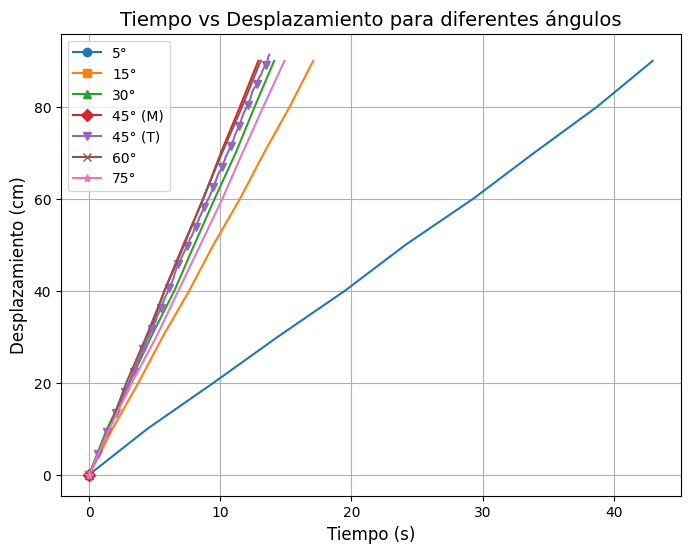

In [16]:
#SECCIÓN 9 - GRAFICA TIEMPO VS POSICION

plt.figure(figsize=(8,6))

colores = plt.cm.tab10.colors
marcadores = ['o','s','^','D','v','x','*','P']

for i, angulo in enumerate(datos_completos):
    t, x, v = datos_completos[angulo]

    # 🔥 Normalizar para que inicien en cero
    t = t - t[0]
    x = x - x[0]

    if isinstance(angulo, str):
        ang_num = ''.join(filter(str.isdigit, angulo))
        sufijo = ''.join(filter(str.isalpha, angulo))
        label_text = f"{ang_num}° ({sufijo})"
    else:
        label_text = f"{angulo}°"

    plt.plot(t, x,
             color=colores[i],
             marker=marcadores[i],
             markevery=20,
             linewidth=1.5,
             label=label_text)

plt.xlabel("Tiempo (s)", fontsize=12)
plt.ylabel("Desplazamiento (cm)", fontsize=12)
plt.title("Tiempo vs Desplazamiento para diferentes ángulos", fontsize=14)
plt.grid(True)
plt.legend()
plt.show()

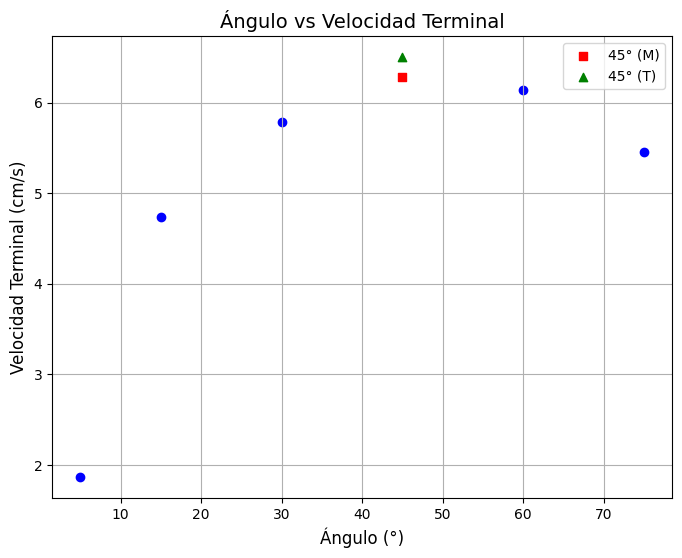

In [17]:
#SECCIÓN 10 — GRÁFICA θ VS VELOCIDAD

plt.figure(figsize=(8,6))

for fila in resultados:
    angulo_original = fila[0]
    ang = float(''.join(filter(str.isdigit, str(angulo_original))))
    v = fila[2]

    if isinstance(angulo_original, str):
        if "M" in angulo_original:
            plt.scatter(ang, v, color="red", marker="s", label="45° (M)")
        elif "T" in angulo_original:
            plt.scatter(ang, v, color="green", marker="^", label="45° (T)")
    else:
        plt.scatter(ang, v, color="blue", marker="o")

plt.xlabel("Ángulo (°)", fontsize=12)
plt.ylabel("Velocidad Terminal (cm/s)", fontsize=12)
plt.title("Ángulo vs Velocidad Terminal", fontsize=14)
plt.grid(True)
plt.legend()
plt.show()

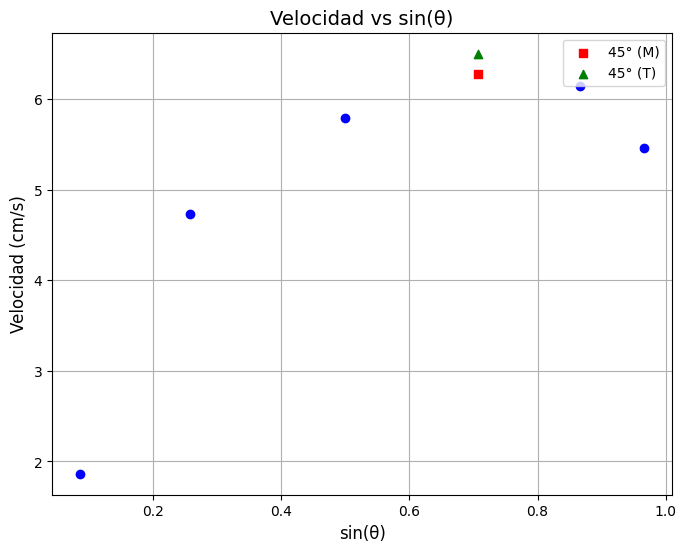

Ecuación ajustada: v = 3.488285 + 0.044886 sin(θ)


In [25]:
# SECCIÓN 11 — GRÁFICA SEN(θ) VS VELOCIDAD

plt.figure(figsize=(8,6))

X_vals = []
Y_vals = []

for fila in resultados:
    angulo_original = fila[0]
    ang = float(''.join(filter(str.isdigit, str(angulo_original))))
    sin_ang = np.sin(np.deg2rad(ang))
    v = fila[2]

    X_vals.append(sin_ang)
    Y_vals.append(v)

    # 🔴 Solo diferenciar 45M y 45T
    if isinstance(angulo_original, str):
        if "M" in angulo_original:
            plt.scatter(sin_ang, v,
                        color="red",
                        marker="s",
                        label="45° (M)")
        elif "T" in angulo_original:
            plt.scatter(sin_ang, v,
                        color="green",
                        marker="^",
                        label="45° (T)")
    else:
        plt.scatter(sin_ang, v,
                    color="blue",
                    marker="o")

plt.xlabel("sin(θ)", fontsize=12)
plt.ylabel("Velocidad (cm/s)", fontsize=12)
plt.title("Velocidad vs sin(θ)", fontsize=14)
plt.grid(True)
plt.legend()
plt.gca().set_facecolor("white")
plt.show()

print(f"Ecuación ajustada: v = {A:.6f} + {B:.6f} sin(θ)")

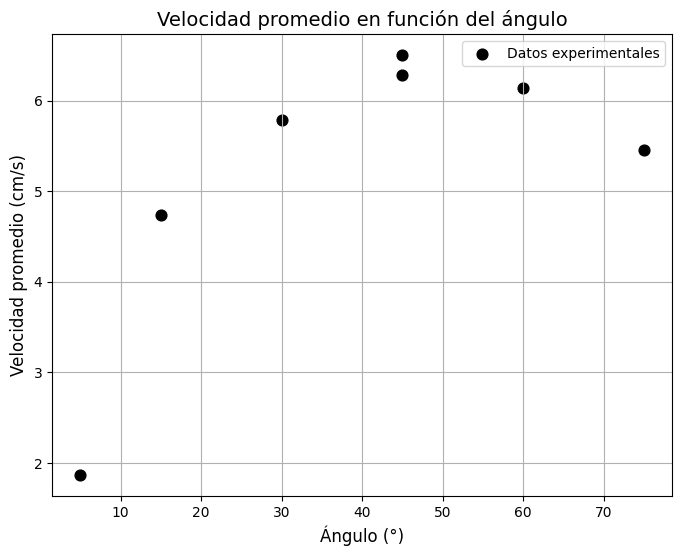

In [19]:
# SECCIÓN 12 — GRAFICA VELOCIDAD vs ANGULO

# Convertir ángulos a valor numérico
X = []
for ang in df_resultados["Ángulo\n(°)"].values:
    ang_num = float(''.join(filter(str.isdigit, str(ang))))
    X.append(ang_num)

Y = df_resultados["Vel prom\n(cm/s)"].values

plt.figure(figsize=(8,6))

plt.scatter(
    X,
    Y,
    color="black",
    marker="o",
    s=60,
    label="Datos experimentales"
)

plt.xlabel("Ángulo (°)", fontsize=12)
plt.ylabel("Velocidad promedio (cm/s)", fontsize=12)
plt.title("Velocidad promedio en función del ángulo", fontsize=14)

plt.grid(True)
plt.gca().set_facecolor("white")
plt.legend()

plt.show()

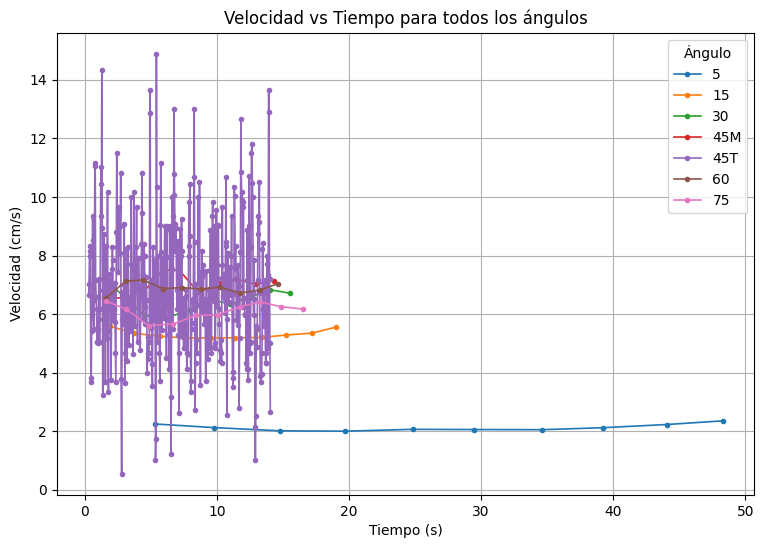

In [20]:
# SECCIÓN 13 — VELOCIDAD vs TIEMPO (TODOS LOS ÁNGULOS)

plt.figure(figsize=(9,6))

for angulo, datos in datos_completos.items():

    t = datos[0]          # tiempo
    d = datos[1]          # distancia
    v = np.gradient(d, t) # velocidad instantánea

    plt.plot(
        t,
        v,
        marker='o',
        markersize=3,
        linewidth=1.2,
        label=str(angulo)
    )

plt.xlabel("Tiempo (s)")
plt.ylabel("Velocidad (cm/s)")
plt.title("Velocidad vs Tiempo para todos los ángulos")
plt.grid(True)
plt.legend(title="Ángulo")

plt.show()

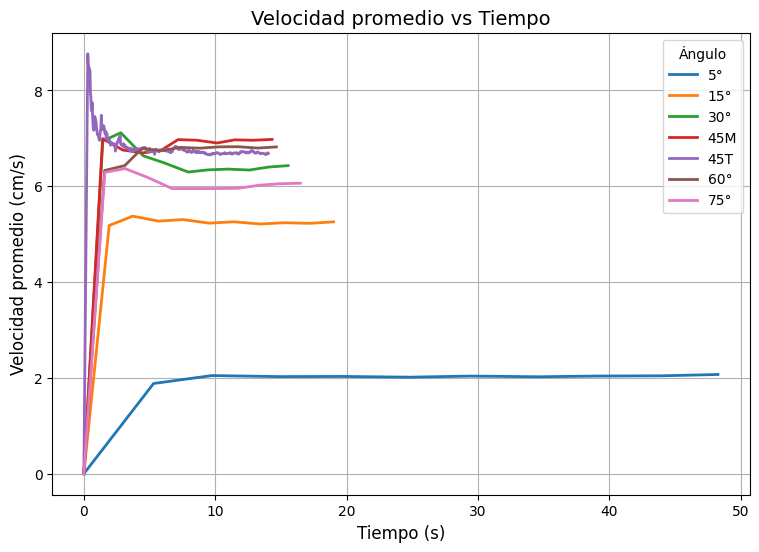

In [21]:
# SECCIÓN 14 — VELOCIDAD PROMEDIO vs TIEMPO (TODOS LOS ÁNGULOS)

plt.figure(figsize=(9,6))

for angulo, archivo in archivos.items():

    df = pd.read_csv(archivo, sep="\t")

    # Limpiar comas y convertir a float manualmente
    t = df.iloc[:,0].astype(str).str.replace(",", ".").astype(float).values
    x = df.iloc[:,1].astype(str).str.replace(",", ".").astype(float).values

    # velocidad promedio acumulada
    v_prom = (x - x[0]) / (t - t[0] + 1e-8)

    # Etiqueta correcta
    if isinstance(angulo, str):
        etiqueta = angulo
    else:
        etiqueta = f"{angulo}°"

    plt.plot(
        t,
        v_prom,
        linewidth=2,
        label=etiqueta
    )

plt.xlabel("Tiempo (s)", fontsize=12)
plt.ylabel("Velocidad promedio (cm/s)", fontsize=12)
plt.title("Velocidad promedio vs Tiempo", fontsize=14)
plt.grid(True)
plt.legend(title="Ángulo")
plt.gca().set_facecolor("white")

plt.show()

In [22]:
print("X =", X)
print("Y =", Y)

X = [5.0, 15.0, 30.0, 45.0, 45.0, 60.0, 75.0]
Y = [1.86413 4.73186 5.78778 6.28053 6.50036 6.13915 5.45785]


In [23]:
# SECCIÓN 12 — ANÁLISIS ESTADÍSITICO

# Convertir a numpy
X = np.array(X, dtype=float)
Y = np.array(Y, dtype=float)

n = len(X)

sum_x = np.sum(X)
sum_y = np.sum(Y)
sum_x2 = np.sum(X**2)
sum_y2 = np.sum(Y**2)
sum_xy = np.sum(X*Y)

delta = n*sum_x2 - sum_x**2

# Parámetros del ajuste
A = (sum_y*sum_x2 - sum_x*sum_xy) / delta
B = (n*sum_xy - sum_x*sum_y) / delta

# Residuos
Y_fit = A + B*X
residuos = Y - Y_fit

SSR = np.sum(residuos**2)

# Varianza residual
sigma2 = SSR / (n - 2)
sigma = np.sqrt(sigma2)

# Incertidumbres
sigma_B = np.sqrt(n * sigma2 / delta)
sigma_A = np.sqrt(sum_x2 * sigma2 / delta)

# Correlación
r = (n*sum_xy - sum_x*sum_y) / np.sqrt(
    (n*sum_x2 - sum_x**2) *
    (n*sum_y2 - sum_y**2)
)

R2 = r**2

print("\nANÁLISIS ESTADÍSTICO")
print(f"Suma de cuadrados residual = {SSR:.6e}")
print(f"Desviación estándar residual = {sigma:.6e}")
print(f"Pendiente B = {B:.6f} ± {sigma_B:.6f}")
print(f"Intercepto A = {A:.6f} ± {sigma_A:.6f}")
print(f"Coeficiente de correlación r = {r:.6f}")
print(f"Coeficiente de determinación R² = {R2:.6f}")


ANÁLISIS ESTADÍSTICO
Suma de cuadrados residual = 8.184649e+00
Desviación estándar residual = 1.279426e+00
Pendiente B = 0.044886 ± 0.021261
Intercepto A = 3.488285 ± 0.965126
Coeficiente de correlación r = 0.686519
Coeficiente de determinación R² = 0.471308
